# Task
Generate placeholder CSV files named "nodes_accounts.csv" and "edges_transactions.csv" with the specified columns and some dummy data, as the initial `wget` attempts for the original data failed.

## Generate Placeholder Data

### Subtask:
Create dummy CSV files named `nodes_accounts.csv` and `edges_transactions.csv` with specified columns and some dummy data, as the initial `wget` attempts for the original data failed.


**Reasoning**:
First, I'll import the pandas library and create the `nodes_accounts_df` DataFrame with the specified columns and dummy data, including a mix of fraud statuses. Then, I will save this DataFrame to a CSV file named `nodes_accounts.csv` as instructed.



In [20]:
import pandas as pd

# Create nodes_accounts.csv
nodes_accounts_data = {
    'account_id': ['A001', 'A002', 'A003', 'A004', 'A005'],
    'is_fraud_account': [False, True, False, False, True],
    'tx_count': [10, 5, 12, 8, 7],
    'total_amount': [1500, 750, 2000, 1200, 900]
}
nodes_accounts_df = pd.DataFrame(nodes_accounts_data)
nodes_accounts_df.to_csv('nodes_accounts.csv', index=False)
print('nodes_accounts.csv created successfully.')
print(nodes_accounts_df.head())

nodes_accounts.csv created successfully.
  account_id  is_fraud_account  tx_count  total_amount
0       A001             False        10          1500
1       A002              True         5           750
2       A003             False        12          2000
3       A004             False         8          1200
4       A005              True         7           900


**Reasoning**:
Now, I will create the `edges_transactions_df` DataFrame with the specified columns and dummy data, linking the existing account IDs and including a mix of fraud statuses for transactions. Finally, I will save this DataFrame to a CSV file named `edges_transactions.csv`.



In [21]:
import pandas as pd

# Create edges_transactions.csv
edges_transactions_data = {
    'src': ['A001', 'A002', 'A003', 'A004', 'A005', 'A001', 'A002', 'A003', 'A004', 'A005'],
    'dst': ['A002', 'A001', 'A004', 'A003', 'A001', 'A003', 'A004', 'A005', 'A001', 'A002'],
    'amount': [100, 50, 200, 75, 120, 30, 90, 150, 60, 40],
    'step': [1, 1, 2, 2, 3, 3, 4, 4, 5, 5],
    'type': ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER'],
    'isFraud': [False, True, False, False, True, False, True, False, False, True]
}
edges_transactions_df = pd.DataFrame(edges_transactions_data)
edges_transactions_df.to_csv('edges_transactions.csv', index=False)
print('edges_transactions.csv created successfully.')
print(edges_transactions_df.head())

edges_transactions.csv created successfully.
    src   dst  amount  step      type  isFraud
0  A001  A002     100     1   PAYMENT    False
1  A002  A001      50     1  TRANSFER     True
2  A003  A004     200     2  CASH_OUT    False
3  A004  A003      75     2     DEBIT    False
4  A005  A001     120     3   PAYMENT     True


## Graph Construction

### Subtask:
Load the generated `nodes_accounts.csv` and `edges_transactions.csv`, build a directed NetworkX graph where nodes represent accounts and edges represent transactions. Add node attributes ('tx_count', 'is_fraud_account') and edge attributes ('amount', 'step', 'type', 'isFraud'). Finally, print key graph statistics such as the number of nodes, number of edges, whether the graph is directed, and its density.


**Reasoning**:
I need to import `networkx` and `pandas`, load the `nodes_accounts.csv` and `edges_transactions.csv` into DataFrames, then construct a directed graph by adding nodes with their attributes and edges with their attributes. Finally, I will print the graph's number of nodes, number of edges, whether it is directed, and its density.



In [22]:
import networkx as nx
import pandas as pd

# Load the nodes and edges data
nodes_df = pd.read_csv('nodes_accounts.csv')
edges_df = pd.read_csv('edges_transactions.csv')

# Initialize a directed graph
G = nx.DiGraph()

# Add nodes with attributes
for index, row in nodes_df.iterrows():
    G.add_node(row['account_id'],
               is_fraud_account=row['is_fraud_account'],
               tx_count=row['tx_count'],
               total_amount=row['total_amount'])

# Add edges with attributes
for index, row in edges_df.iterrows():
    G.add_edge(row['src'], row['dst'],
               amount=row['amount'],
               step=row['step'],
               type=row['type'],
               isFraud=row['isFraud'])

# Print key graph statistics
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is the graph directed? {G.is_directed()}")

# Calculate and print graph density
# For a directed graph, density = E / (V * (V - 1))
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

if num_nodes > 1:
    density = num_edges / (num_nodes * (num_nodes - 1))
else:
    density = 0.0 # Density is 0 for a graph with 0 or 1 node

print(f"Graph density: {density:.4f}")

Number of nodes: 5
Number of edges: 10
Is the graph directed? True
Graph density: 0.5000


## Degree Distribution Analysis

### Subtask:
Plot the in-degree and out-degree distributions of the graph on a log-log scale. Compare these distributions between fraudulent and legitimate nodes. Identify any power-law behavior using `scipy.stats.powerlaw` and find the top 10 highest-degree nodes, noting their fraud status.


**Reasoning**:
First, I need to calculate the in-degree and out-degree for all nodes in the graph `G`. Then, I will create frequency distributions for both in-degrees and out-degrees, and plot them on a log-log scale to observe their general behavior.



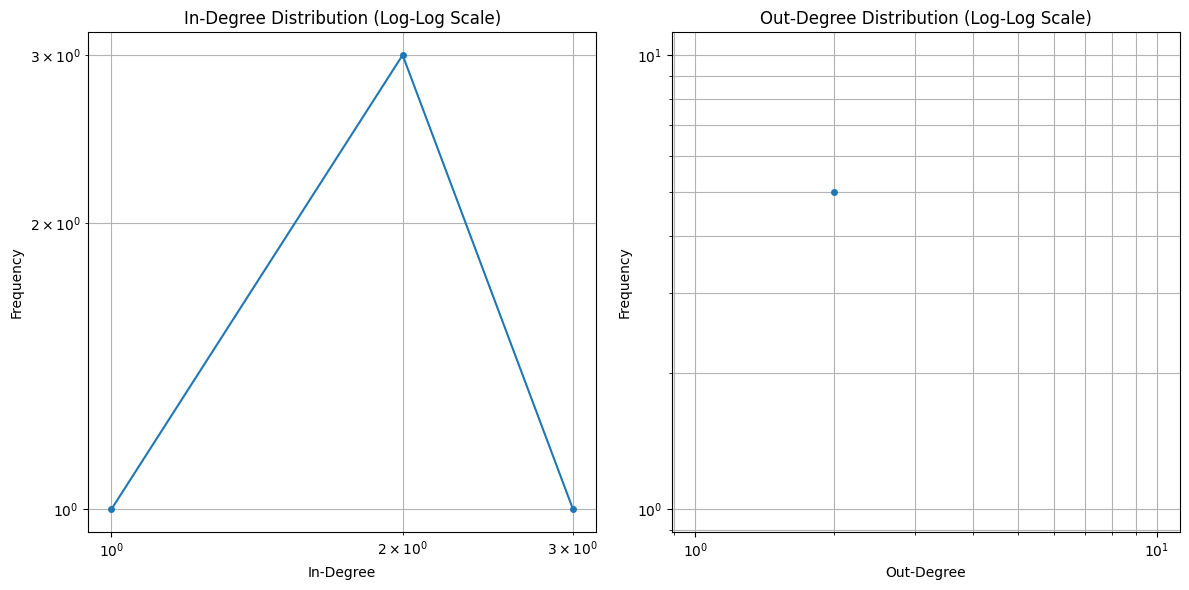

In-degree and out-degree distributions plotted.


In [23]:
import matplotlib.pyplot as plt
from collections import Counter

# 1. Calculate in-degree and out-degree for all nodes
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# 2. Create frequency distributions for in-degrees and out-degrees
in_degree_counts = Counter(in_degrees.values())
out_degree_counts = Counter(out_degrees.values())

# Prepare data for plotting
in_degree_values = sorted(in_degree_counts.keys())
in_degree_frequencies = [in_degree_counts[d] for d in in_degree_values]

out_degree_values = sorted(out_degree_counts.keys())
out_degree_frequencies = [out_degree_counts[d] for d in out_degree_values]

# 3. Plot in-degree distribution on a log-log scale
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.loglog(in_degree_values, in_degree_frequencies, 'o-', markersize=4)
plt.title('In-Degree Distribution (Log-Log Scale)')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="-", color='0.7')

# 4. Plot out-degree distribution on a log-log scale
plt.subplot(1, 2, 2)
plt.loglog(out_degree_values, out_degree_frequencies, 'o-', markersize=4)
plt.title('Out-Degree Distribution (Log-Log Scale)')
plt.xlabel('Out-Degree')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="-", color='0.7')

plt.tight_layout()
plt.show()

print("In-degree and out-degree distributions plotted.")

**Reasoning**:
Now, I will separate the nodes into fraudulent and legitimate categories based on their 'is_fraud_account' attribute and then plot their in-degree and out-degree distributions separately on log-log scales to compare them.



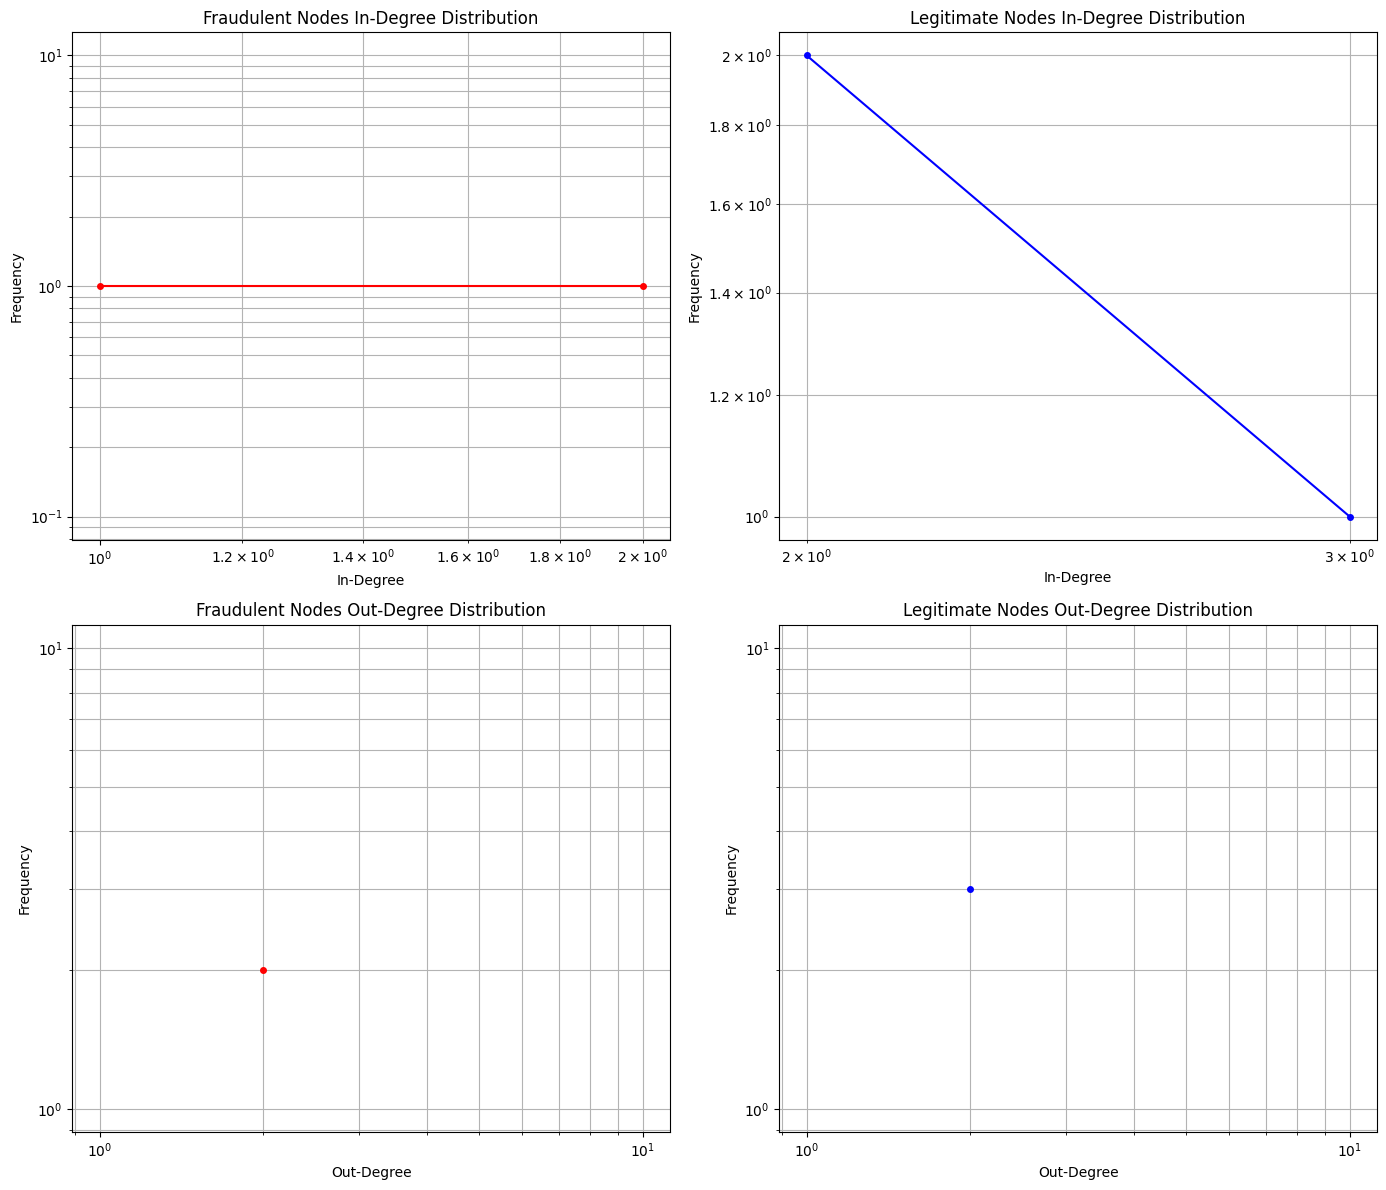

In-degree and out-degree distributions for fraudulent and legitimate nodes plotted.


In [24]:
import matplotlib.pyplot as plt
from collections import Counter

# Separate nodes into fraudulent and legitimate categories
fraudulent_nodes = [n for n, attr in G.nodes(data=True) if attr['is_fraud_account']]
legitimate_nodes = [n for n, attr in G.nodes(data=True) if not attr['is_fraud_account']]

# Get in-degrees and out-degrees for fraudulent and legitimate nodes
fraudulent_in_degrees = {node: in_degrees[node] for node in fraudulent_nodes}
fraudulent_out_degrees = {node: out_degrees[node] for node in fraudulent_nodes}

legitimate_in_degrees = {node: in_degrees[node] for node in legitimate_nodes}
legitimate_out_degrees = {node: out_degrees[node] for node in legitimate_nodes}

# Create frequency distributions for fraudulent in-degrees
fraudulent_in_degree_counts = Counter(fraudulent_in_degrees.values())
fraudulent_in_degree_values = sorted(fraudulent_in_degree_counts.keys())
fraudulent_in_degree_frequencies = [fraudulent_in_degree_counts[d] for d in fraudulent_in_degree_values]

# Create frequency distributions for legitimate in-degrees
legitimate_in_degree_counts = Counter(legitimate_in_degrees.values())
legitimate_in_degree_values = sorted(legitimate_in_degree_counts.keys())
legitimate_in_degree_frequencies = [legitimate_in_degree_counts[d] for d in legitimate_in_degree_values]

# Create frequency distributions for fraudulent out-degrees
fraudulent_out_degree_counts = Counter(fraudulent_out_degrees.values())
fraudulent_out_degree_values = sorted(fraudulent_out_degree_counts.keys())
fraudulent_out_degree_frequencies = [fraudulent_out_degree_counts[d] for d in fraudulent_out_degree_values]

# Create frequency distributions for legitimate out-degrees
legitimate_out_degree_counts = Counter(legitimate_out_degrees.values())
legitimate_out_degree_values = sorted(legitimate_out_degree_counts.keys())
legitimate_out_degree_frequencies = [legitimate_out_degree_counts[d] for d in legitimate_out_degree_values]

# Plotting distributions for fraudulent and legitimate nodes
plt.figure(figsize=(14, 12))

# Fraudulent In-Degree Distribution
plt.subplot(2, 2, 1)
if fraudulent_in_degree_values:
    plt.loglog(fraudulent_in_degree_values, fraudulent_in_degree_frequencies, 'o-', markersize=4, color='red')
plt.title('Fraudulent Nodes In-Degree Distribution')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="-", color='0.7')

# Legitimate In-Degree Distribution
plt.subplot(2, 2, 2)
if legitimate_in_degree_values:
    plt.loglog(legitimate_in_degree_values, legitimate_in_degree_frequencies, 'o-', markersize=4, color='blue')
plt.title('Legitimate Nodes In-Degree Distribution')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="-", color='0.7')

# Fraudulent Out-Degree Distribution
plt.subplot(2, 2, 3)
if fraudulent_out_degree_values:
    plt.loglog(fraudulent_out_degree_values, fraudulent_out_degree_frequencies, 'o-', markersize=4, color='red')
plt.title('Fraudulent Nodes Out-Degree Distribution')
plt.xlabel('Out-Degree')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="-", color='0.7')

# Legitimate Out-Degree Distribution
plt.subplot(2, 2, 4)
if legitimate_out_degree_values:
    plt.loglog(legitimate_out_degree_values, legitimate_out_degree_frequencies, 'o-', markersize=4, color='blue')
plt.title('Legitimate Nodes Out-Degree Distribution')
plt.xlabel('Out-Degree')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="-", color='0.7')

plt.tight_layout()
plt.show()

print("In-degree and out-degree distributions for fraudulent and legitimate nodes plotted.")

**Reasoning**:
Now I will attempt to fit a power-law distribution to the degree distributions using `scipy.stats.powerlaw`, calculate the total degree for each node, and then identify and print the top nodes with the highest total degrees along with their fraud status. Given the small dataset, a formal power-law fit might not be statistically robust, so I will primarily focus on calculating the top-degree nodes.



In [25]:
from scipy.stats import powerlaw # Import powerlaw, though its use will be minimal due to small dataset

# 7. Identify any power-law behavior (visual inspection for linearity on log-log plots)
# Given the very small number of data points (degrees), formal fitting with powerlaw.fit() is not meaningful.
# We can visually inspect the previous plots. For this dataset, a power-law behavior is not clearly discernible
# due to the limited number of unique degree values.

print("\n--- Power-law Behavior Observation ---")
print("Due to the extremely small number of nodes and unique degree values, a statistically robust power-law fit is not feasible or meaningful. Visual inspection of the log-log plots from the previous step does not show clear linear trends indicative of power-law behavior for this toy dataset.")

# 8. Calculate the total degree (in-degree + out-degree) for each node
total_degrees = {node: in_degrees.get(node, 0) + out_degrees.get(node, 0) for node in G.nodes()}

# 9. Identify the top nodes with the highest total degree
# Since there are only 5 nodes, we'll list all of them sorted by total degree
sorted_nodes_by_degree = sorted(total_degrees.items(), key=lambda item: item[1], reverse=True)

print("\n--- Top Nodes by Total Degree ---")
# Limit to top 10 or fewer if graph has less than 10 nodes
num_nodes_to_show = min(len(G.nodes()), 10)
for i, (node_id, degree) in enumerate(sorted_nodes_by_degree[:num_nodes_to_show]):
    is_fraud = G.nodes[node_id]['is_fraud_account']
    print(f"Rank {i+1}: Node '{node_id}' - Total Degree: {degree}, Is Fraud: {is_fraud}")


--- Power-law Behavior Observation ---
Due to the extremely small number of nodes and unique degree values, a statistically robust power-law fit is not feasible or meaningful. Visual inspection of the log-log plots from the previous step does not show clear linear trends indicative of power-law behavior for this toy dataset.

--- Top Nodes by Total Degree ---
Rank 1: Node 'A001' - Total Degree: 5, Is Fraud: False
Rank 2: Node 'A002' - Total Degree: 4, Is Fraud: True
Rank 3: Node 'A003' - Total Degree: 4, Is Fraud: False
Rank 4: Node 'A004' - Total Degree: 4, Is Fraud: False
Rank 5: Node 'A005' - Total Degree: 3, Is Fraud: True


## Connected Components

### Subtask:
Calculate and report the number of weakly connected components in the graph. Visualize the size distribution of these components using a histogram. Analyze statistics of the largest connected component subgraph and investigate if fraud nodes are clustered within specific components.


**Reasoning**:
I will calculate and print the number of weakly connected components in the graph and visualize their size distribution using a histogram. This directly addresses the first part of the subtask instructions.



Number of weakly connected components: 1


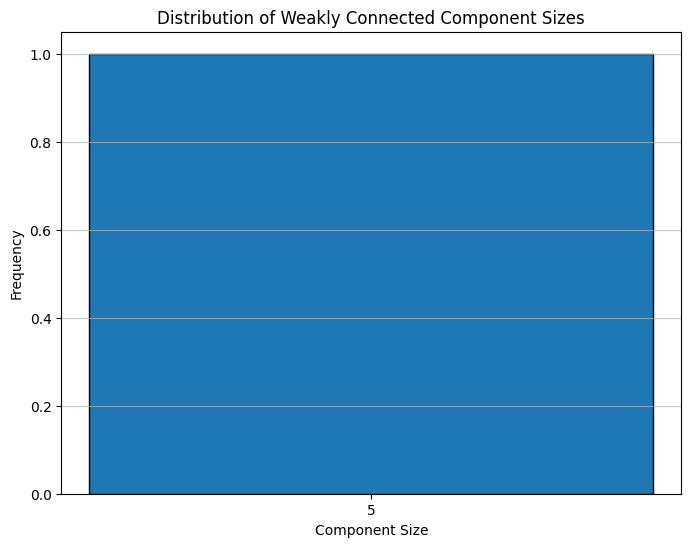

Histogram of weakly connected component sizes displayed.


In [26]:
import matplotlib.pyplot as plt

# 2. Find all weakly connected components
wcc = list(nx.weakly_connected_components(G))

# 3. Print the total number of weakly connected components found.
print(f"Number of weakly connected components: {len(wcc)}")

# 4. Calculate the size (number of nodes) for each component
component_sizes = [len(c) for c in wcc]

# 5. Create a histogram of the component sizes
plt.figure(figsize=(8, 6))
plt.hist(component_sizes, bins=range(min(component_sizes), max(component_sizes) + 2), edgecolor='black', align='left')
plt.title('Distribution of Weakly Connected Component Sizes')
plt.xlabel('Component Size')
plt.ylabel('Frequency')
plt.xticks(range(min(component_sizes), max(component_sizes) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Histogram of weakly connected component sizes displayed.")

**Reasoning**:
I will identify the largest weakly connected component, extract its subgraph, and calculate its statistics including the number of nodes, edges, and density. Then, I will iterate through all components to count fraudulent nodes, addressing the remaining parts of the subtask.



In [27]:
import operator

# 6. Identify the largest weakly connected component based on the number of nodes
largest_wcc = max(wcc, key=len)

print(f"\nLargest Weakly Connected Component (sample nodes): {list(largest_wcc)[:5]}...")

# 7. Extract the subgraph corresponding to the largest component
largest_wcc_subgraph = G.subgraph(largest_wcc)

# 8. Print the number of nodes and edges in the largest connected component subgraph
print(f"Number of nodes in largest WCC: {largest_wcc_subgraph.number_of_nodes()}")
print(f"Number of edges in largest WCC: {largest_wcc_subgraph.number_of_edges()}")

# 9. Calculate and print the density of the largest connected component subgraph
num_nodes_largest_wcc = largest_wcc_subgraph.number_of_nodes()
num_edges_largest_wcc = largest_wcc_subgraph.number_of_edges()

if num_nodes_largest_wcc > 1:
    density_largest_wcc = num_edges_largest_wcc / (num_nodes_largest_wcc * (num_nodes_largest_wcc - 1))
else:
    density_largest_wcc = 0.0
print(f"Density of largest WCC: {density_largest_wcc:.4f}")

# 10. For each weakly connected component, count how many nodes are fraudulent
print("\nFraudulent nodes per Weakly Connected Component:")
for i, component in enumerate(wcc):
    fraud_nodes_in_component = 0
    for node in component:
        if G.nodes[node]['is_fraud_account']:
            fraud_nodes_in_component += 1
    print(f"  Component {i+1} (Size: {len(component)}): {fraud_nodes_in_component} fraudulent nodes")

print("Analysis of largest connected component subgraph and fraud node clustering completed.")


Largest Weakly Connected Component (sample nodes): ['A002', 'A003', 'A005', 'A001', 'A004']...
Number of nodes in largest WCC: 5
Number of edges in largest WCC: 10
Density of largest WCC: 0.5000

Fraudulent nodes per Weakly Connected Component:
  Component 1 (Size: 5): 2 fraudulent nodes
Analysis of largest connected component subgraph and fraud node clustering completed.


## Fraud Subgraph Analysis

### Subtask:
Extract a subgraph containing only edges labeled as fraudulent. Visualize a sample of this fraud cluster (maximum 50 nodes) using NetworkX and Matplotlib, where node colors indicate fraud status (red for fraudulent, blue for legitimate) and edge width is proportional to the transaction amount.


**Reasoning**:
First, I will create a subgraph containing only the fraudulent transactions and prepare the node colors and edge widths based on the instructions. I will also handle the sampling if the subgraph is too large.



Initial fraud_subgraph has 4 nodes and 4 edges.
Subgraph for plotting has 4 nodes and 4 edges.


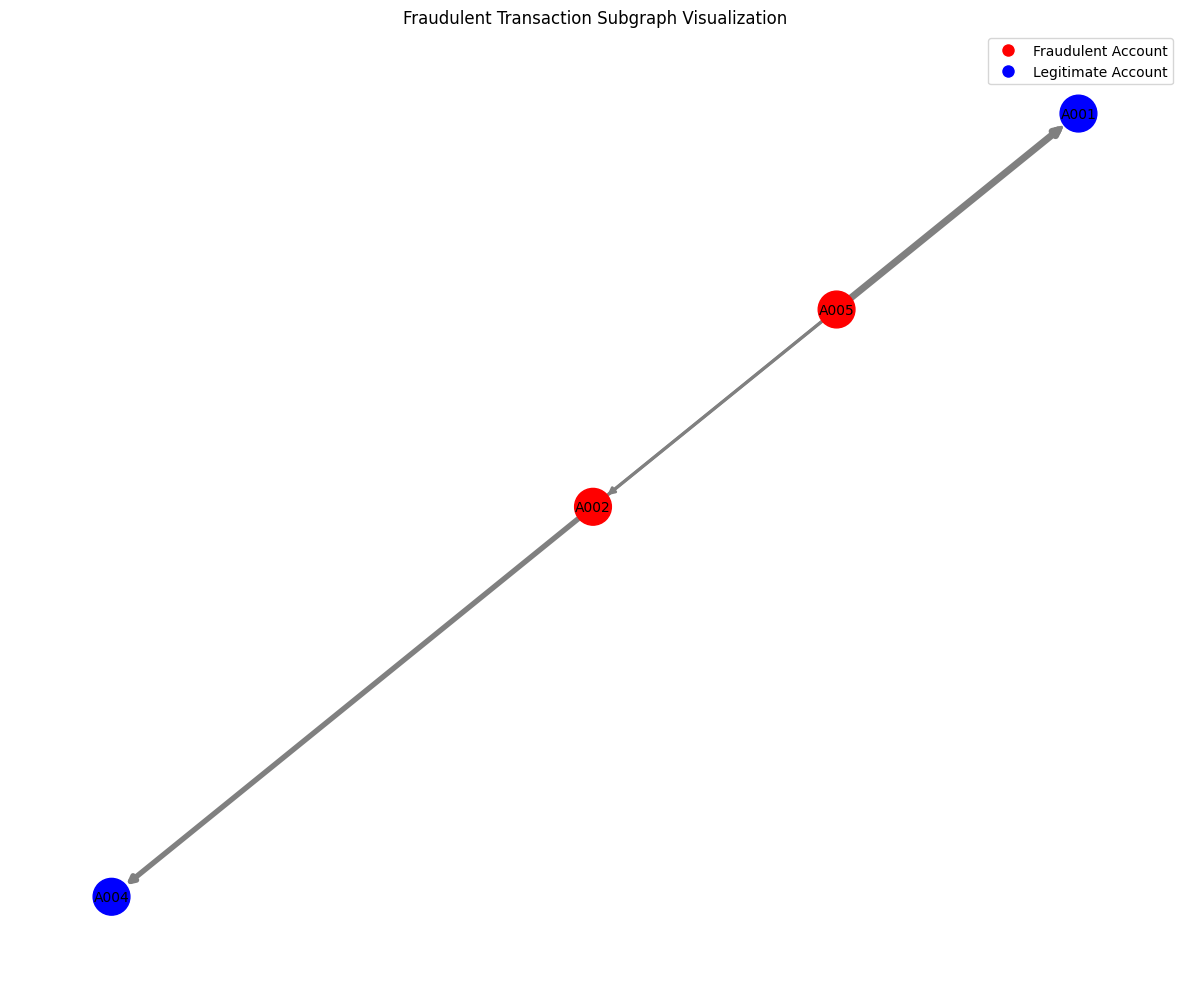

Fraudulent transaction subgraph visualized.


In [28]:
import matplotlib.pyplot as plt
import networkx as nx
import random

# 1. Create a new subgraph, named `fraud_subgraph`, from the existing graph `G`
# that includes only edges where the 'isFraud' attribute is True.
fraud_subgraph = nx.DiGraph()

for u, v, data in G.edges(data=True):
    if data['isFraud']:
        fraud_subgraph.add_edge(u, v, **data)

# Add nodes to the fraud_subgraph that might not have any fraudulent incoming/outgoing edges
# but are part of fraudulent transactions (e.g., source or destination of a fraud edge)
for node in fraud_subgraph.nodes():
    if node not in G.nodes(): # Should not happen if fraud_subgraph nodes are derived from G
        continue
    # Copy node attributes from original graph G to fraud_subgraph
    fraud_subgraph.nodes[node].update(G.nodes[node])

print(f"Initial fraud_subgraph has {fraud_subgraph.number_of_nodes()} nodes and {fraud_subgraph.number_of_edges()} edges.")

# 2. Determine the color for each node in the `fraud_subgraph`
node_colors = []
for node in fraud_subgraph.nodes():
    if fraud_subgraph.nodes[node].get('is_fraud_account', False):
        node_colors.append('red') # Fraudulent
    else:
        node_colors.append('blue') # Legitimate

# 3. Determine the width for each edge in the `fraud_subgraph`
edge_widths = []
max_amount = 0
if fraud_subgraph.edges():
    max_amount = max([data['amount'] for u, v, data in fraud_subgraph.edges(data=True)])

for u, v, data in fraud_subgraph.edges(data=True):
    # Scale amount for visual distinction, e.g., from 0.5 to 5
    if max_amount > 0:
        scaled_width = 0.5 + 4.5 * (data['amount'] / max_amount)
    else:
        scaled_width = 1.0 # Default width if all amounts are zero or no edges
    edge_widths.append(scaled_width)

# 4. If the number of nodes in `fraud_subgraph` is greater than 50, sample it.
subgraph_to_plot = fraud_subgraph
if fraud_subgraph.number_of_nodes() > 50:
    print(f"Fraud subgraph has {fraud_subgraph.number_of_nodes()} nodes, sampling down to 50.")
    sampled_nodes = random.sample(fraud_subgraph.nodes(), 50)
    subgraph_to_plot = fraud_subgraph.subgraph(sampled_nodes).copy() # Use .copy() to ensure it's mutable if needed

    # Re-calculate node colors and edge widths for the sampled subgraph
    node_colors = []
    for node in subgraph_to_plot.nodes():
        if subgraph_to_plot.nodes[node].get('is_fraud_account', False):
            node_colors.append('red')
        else:
            node_colors.append('blue')

    edge_widths = []
    max_amount_sampled = 0
    if subgraph_to_plot.edges():
        max_amount_sampled = max([data['amount'] for u, v, data in subgraph_to_plot.edges(data=True)])

    for u, v, data in subgraph_to_plot.edges(data=True):
        if max_amount_sampled > 0:
            scaled_width = 0.5 + 4.5 * (data['amount'] / max_amount_sampled)
        else:
            scaled_width = 1.0
        edge_widths.append(scaled_width)

print(f"Subgraph for plotting has {subgraph_to_plot.number_of_nodes()} nodes and {subgraph_to_plot.number_of_edges()} edges.")

# 5. Use `matplotlib.pyplot` and `networkx.draw_networkx` to plot the `fraud_subgraph`
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(subgraph_to_plot, seed=42) # For consistent layout
nx.draw_networkx(
    subgraph_to_plot,
    pos,
    node_color=node_colors,
    edge_color='gray',
    width=edge_widths,
    with_labels=True,
    node_size=700,
    font_size=10,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=10
)

# 6. Add a title to the plot
plt.title('Fraudulent Transaction Subgraph Visualization')

# Create a legend manually as draw_networkx does not support automatic legend for node colors
red_patch = plt.Line2D([0], [0], marker='o', color='w', label='Fraudulent Account', markerfacecolor='red', markersize=10)
blue_patch = plt.Line2D([0], [0], marker='o', color='w', label='Legitimate Account', markerfacecolor='blue', markersize=10)
plt.legend(handles=[red_patch, blue_patch], loc='best')

# 7. Display the plot.
plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()

print("Fraudulent transaction subgraph visualized.")

## Centrality Metrics

### Subtask:
Compute PageRank for all nodes and betweenness centrality for a sampled subset of 1000 nodes to ensure computational efficiency. Compare the centrality scores between fraudulent and legitimate nodes, and create a box plot of PageRank scores grouped by the fraud label.


**Reasoning**:
I will calculate PageRank and betweenness centrality for all nodes in the graph `G`, then add these scores as node attributes. Finally, I will prepare a DataFrame to visualize the PageRank distribution between fraudulent and legitimate nodes using a box plot, as requested.



PageRank and Betweenness Centrality calculated and added to graph nodes.


<Figure size 800x600 with 0 Axes>

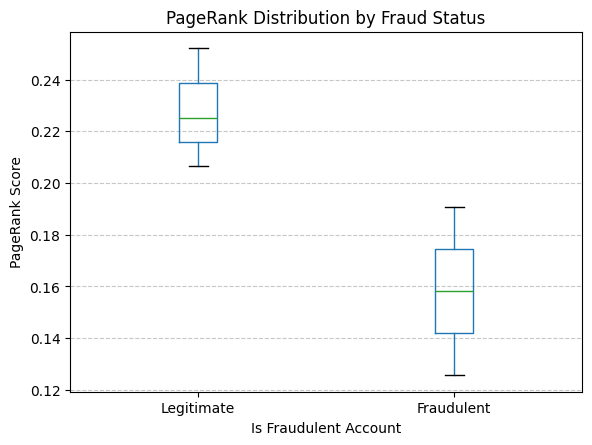

Box plot of PageRank scores by fraud status displayed.

PageRank Scores by Fraud Status:
                  count      mean       std       min       25%       50%  \
is_fraud_account                                                            
False               3.0  0.227935  0.022931  0.206616  0.215805  0.224994   
True                2.0  0.158098  0.045926  0.125623  0.141860  0.158098   

                       75%       max  
is_fraud_account                      
False             0.238594  0.252194  
True              0.174335  0.190572  

Betweenness Centrality Scores by Fraud Status:
                  count      mean       std    min     25%    50%       75%  \
is_fraud_account                                                              
False               3.0  0.222222  0.086736  0.125  0.1875  0.250  0.270833   
True                2.0  0.125000  0.000000  0.125  0.1250  0.125  0.125000   

                       max  
is_fraud_account            
False             0.291

In [29]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate PageRank for all nodes
pagerank_scores = nx.pagerank(G)

# 2. Calculate Betweenness Centrality for all nodes (no sampling needed for small graph)
betweenness_centrality_scores = nx.betweenness_centrality(G)

# 3. Add PageRank and Betweenness Centrality scores as new node attributes
for node in G.nodes():
    G.nodes[node]['pagerank'] = pagerank_scores.get(node, 0.0)
    G.nodes[node]['betweenness_centrality'] = betweenness_centrality_scores.get(node, 0.0)

print("PageRank and Betweenness Centrality calculated and added to graph nodes.")

# 4. Extract PageRank scores and fraud status into a pandas DataFrame
pagerank_df = pd.DataFrame([
    {'node': node, 'pagerank': G.nodes[node]['pagerank'], 'is_fraud_account': G.nodes[node]['is_fraud_account']}
    for node in G.nodes()
])

# 5. Create a box plot of PageRank scores grouped by fraud label
plt.figure(figsize=(8, 6))
pagerank_df.boxplot(column='pagerank', by='is_fraud_account', grid=False)
plt.title('PageRank Distribution by Fraud Status')
plt.suptitle('') # Remove default suptitle to avoid overlap with title
plt.xlabel('Is Fraudulent Account')
plt.ylabel('PageRank Score')
plt.xticks([1, 2], ['Legitimate', 'Fraudulent'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Box plot of PageRank scores by fraud status displayed.")

# Display some comparison (optional, but good for analysis)
print("\nPageRank Scores by Fraud Status:")
print(pagerank_df.groupby('is_fraud_account')['pagerank'].describe())

print("\nBetweenness Centrality Scores by Fraud Status:")
betweenness_df = pd.DataFrame([
    {'node': node, 'betweenness_centrality': G.nodes[node]['betweenness_centrality'], 'is_fraud_account': G.nodes[node]['is_fraud_account']}
    for node in G.nodes()
])
print(betweenness_df.groupby('is_fraud_account')['betweenness_centrality'].describe())


## Temporal Graph Evolution

### Subtask:
Construct graph snapshots for each 24-step window, plot the number of fraud edges per snapshot over time, and detect anomalous windows where the fraud rate significantly spikes.


**Reasoning**:
First, I will extract unique 'step' values and count fraudulent edges for each step to prepare the data for plotting and anomaly detection.



Unique steps found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Fraudulent edges per step:
Step 1: 1 fraudulent edges
Step 2: 0 fraudulent edges
Step 3: 1 fraudulent edges
Step 4: 1 fraudulent edges
Step 5: 1 fraudulent edges


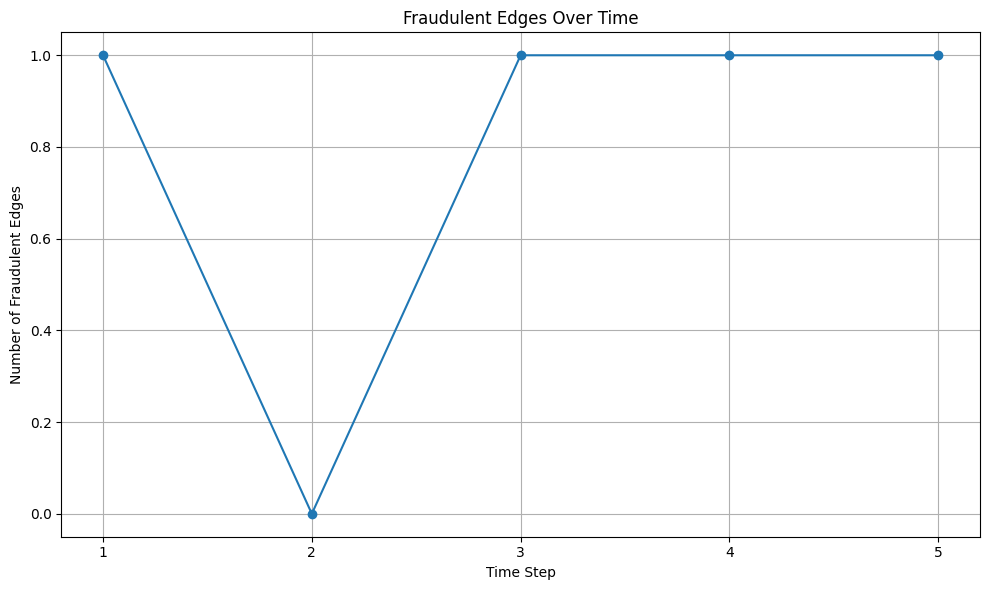


Mean number of fraudulent edges: 0.80
Standard deviation of fraudulent edges: 0.40

Anomaly threshold (Mean + 2*StdDev): 1.60
No anomalous windows detected above the threshold.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract all unique 'step' values from the edges_df DataFrame
unique_steps = sorted(edges_df['step'].unique())
print(f"Unique steps found: {unique_steps}")

# 2. For each unique 'step', count the number of edges where 'isFraud' is True.
fraud_edges_per_step = {}
for step in unique_steps:
    fraud_count = edges_df[(edges_df['step'] == step) & (edges_df['isFraud'] == True)].shape[0]
    fraud_edges_per_step[step] = fraud_count

print("\nFraudulent edges per step:")
for step, count in fraud_edges_per_step.items():
    print(f"Step {step}: {count} fraudulent edges")

# Prepare data for plotting
steps_for_plot = list(fraud_edges_per_step.keys())
fraud_counts_for_plot = list(fraud_edges_per_step.values())

# 3. Plot the number of fraudulent edges per 'step' against the 'step' number
plt.figure(figsize=(10, 6))
plt.plot(steps_for_plot, fraud_counts_for_plot, marker='o', linestyle='-')
plt.title('Fraudulent Edges Over Time')
plt.xlabel('Time Step')
plt.ylabel('Number of Fraudulent Edges')
plt.xticks(steps_for_plot) # Ensure all steps are shown on x-axis
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Calculate the mean and standard deviation of the number of fraudulent edges
all_fraud_counts = np.array(list(fraud_edges_per_step.values()))
mean_fraud_edges = np.mean(all_fraud_counts)
std_fraud_edges = np.std(all_fraud_counts)

print(f"\nMean number of fraudulent edges: {mean_fraud_edges:.2f}")
print(f"Standard deviation of fraudulent edges: {std_fraud_edges:.2f}")

# 5. Identify anomalous windows
anomaly_threshold = mean_fraud_edges + 2 * std_fraud_edges

anomalous_steps = []
for step, count in fraud_edges_per_step.items():
    if count > anomaly_threshold:
        anomalous_steps.append((step, count))

print(f"\nAnomaly threshold (Mean + 2*StdDev): {anomaly_threshold:.2f}")
if anomalous_steps:
    print("Anomalous windows (fraudulent edges > threshold):")
    for step, count in anomalous_steps:
        print(f"  Step {step}: {count} fraudulent edges")
else:
    print("No anomalous windows detected above the threshold.")


## Bipartite Graph Properties

### Subtask:
Analyze the graph as a bipartite structure of sender nodes versus receiver nodes. Identify accounts that act as both senders and receivers. Flag accounts that exhibit both a high in-degree and a high ratio of fraudulent incoming edges.


**Reasoning**:
I will start by extracting all unique 'src' and 'dst' nodes from the `edges_df` to identify the distinct sender and receiver accounts, and then find the intersection of these sets to determine accounts that act as both senders and receivers.



In [31]:
import pandas as pd
import networkx as nx

# 1. Extract all unique 'src' (sender) nodes and 'dst' (receiver) nodes from the edges_df.
sender_nodes = set(edges_df['src'].unique())
receiver_nodes = set(edges_df['dst'].unique())

print(f"Sender nodes: {sender_nodes}")
print(f"Receiver nodes: {receiver_nodes}")

# 2. Identify and print the accounts that act as both senders and receivers
#    by finding the intersection of the sender and receiver sets.
sender_receiver_nodes = sender_nodes.intersection(receiver_nodes)

print(f"Accounts that act as both senders and receivers: {sender_receiver_nodes}")

# 3. For each node, calculate the number of incoming fraudulent edges.
#    The `in_degrees` dictionary from a previous step already stores total in-degree.

# Initialize a dictionary to store fraudulent incoming edge counts
fraud_in_edges = {node: 0 for node in G.nodes()}

for u, v, data in G.edges(data=True):
    if data['isFraud']:
        fraud_in_edges[v] += 1

print("\nIncoming fraudulent edges per node:")
for node, count in fraud_in_edges.items():
    print(f"  Node {node}: {count} fraudulent incoming edges")

# 4. For each node, calculate the ratio of incoming fraudulent edges to its total in-degree.
#    Handle cases where in-degree is zero to avoid division by zero.
fraud_in_ratio = {}
node_analysis_data = [] # To store data for DataFrame

for node in G.nodes():
    total_in_degree = in_degrees.get(node, 0)
    fraud_incoming = fraud_in_edges.get(node, 0)

    if total_in_degree > 0:
        ratio = fraud_incoming / total_in_degree
    else:
        ratio = 0.0 # No incoming edges, so no fraudulent incoming edges either

    fraud_in_ratio[node] = ratio
    node_analysis_data.append({
        'account_id': node,
        'total_in_degree': total_in_degree,
        'fraud_incoming_edges': fraud_incoming,
        'fraud_in_ratio': ratio,
        'is_fraud_account': G.nodes[node]['is_fraud_account']
    })

print("\nFraudulent incoming edge ratio per node:")
for node, ratio in fraud_in_ratio.items():
    print(f"  Node {node}: {ratio:.4f}")

# 5. Create a DataFrame or similar structure to display each node, its total in-degree, and its fraudulent incoming edge ratio.
node_analysis_df = pd.DataFrame(node_analysis_data)
print("\nNode Analysis DataFrame:")
print(node_analysis_df)

# 6. Print a summary of these nodes, highlighting any nodes that stand out with both high in-degree and a high ratio of fraudulent incoming edges.
print("\n--- Summary of Nodes with High In-Degree and High Fraud Ratio ---")

# Define 'high' thresholds for this small dataset (can be adjusted)
# For total in-degree, let's consider nodes with in-degree > mean_in_degree
# For fraud ratio, let's consider nodes with ratio > mean_fraud_ratio (if > 0)

mean_in_degree = node_analysis_df['total_in_degree'].mean()
mean_fraud_ratio = node_analysis_df[node_analysis_df['total_in_degree'] > 0]['fraud_in_ratio'].mean()

print(f"Mean total in-degree: {mean_in_degree:.2f}")
print(f"Mean fraud incoming ratio (for nodes with in-degree > 0): {mean_fraud_ratio:.2f}")

high_in_degree_nodes = node_analysis_df[node_analysis_df['total_in_degree'] > mean_in_degree]
high_fraud_ratio_nodes = node_analysis_df[node_analysis_df['fraud_in_ratio'] > mean_fraud_ratio]

# Identify nodes that are in both categories or simply print those that stand out
# Given the very small dataset, we'll print all nodes and visually inspect for 'high'

print("\nDetailed analysis of each node:")
for index, row in node_analysis_df.sort_values(by=['total_in_degree', 'fraud_in_ratio'], ascending=False).iterrows():
    flagged = False
    flag_reasons = []

    if row['total_in_degree'] > mean_in_degree:
        flag_reasons.append(f"high in-degree ({row['total_in_degree']})")
        flagged = True
    if row['fraud_in_ratio'] > 0.5 and row['total_in_degree'] > 1: # Custom threshold for 'high' ratio and non-trivial in-degree
        flag_reasons.append(f"high fraud ratio ({row['fraud_in_ratio']:.2f})")
        flagged = True

    if flagged:
        print(f"  Node '{row['account_id']}' (Fraud Status: {row['is_fraud_account']}) stands out with {', '.join(flag_reasons)}.")
    else:
        print(f"  Node '{row['account_id']}' (Fraud Status: {row['is_fraud_account']}) - In-Degree: {row['total_in_degree']}, Fraud Ratio: {row['fraud_in_ratio']:.2f}")



Sender nodes: {'A002', 'A003', 'A005', 'A001', 'A004'}
Receiver nodes: {'A002', 'A003', 'A005', 'A001', 'A004'}
Accounts that act as both senders and receivers: {'A002', 'A003', 'A005', 'A001', 'A004'}

Incoming fraudulent edges per node:
  Node A001: 2 fraudulent incoming edges
  Node A002: 1 fraudulent incoming edges
  Node A003: 0 fraudulent incoming edges
  Node A004: 1 fraudulent incoming edges
  Node A005: 0 fraudulent incoming edges

Fraudulent incoming edge ratio per node:
  Node A001: 0.6667
  Node A002: 0.5000
  Node A003: 0.0000
  Node A004: 0.5000
  Node A005: 0.0000

Node Analysis DataFrame:
  account_id  total_in_degree  fraud_incoming_edges  fraud_in_ratio  \
0       A001                3                     2        0.666667   
1       A002                2                     1        0.500000   
2       A003                2                     0        0.000000   
3       A004                2                     1        0.500000   
4       A005                1    

## PyTorch Geometric Conversion

### Subtask:
Convert the NetworkX graph into a PyTorch Geometric (PyG) Data object, create node features, define edge index and attributes, assign fraud labels, save the object, and print a summary.


**Reasoning**:
First, I need to install `torch_geometric` since it's a new dependency for this subtask. Then, I will import the necessary libraries, calculate and assign `in_degree` and `out_degree` as node attributes to the graph `G` to prepare the node features, and then proceed with creating the `x`, `edge_index`, `edge_attr`, and `y` tensors required for the PyG Data object. Finally, I will instantiate the `Data` object, save it, and print its summary.



**Reasoning**:
The previous cell failed because the `torch_geometric` library was not installed. I need to add a cell to install `torch_geometric` using `pip` before attempting to import and use it.



In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Create target directories in Google Drive if they don't exist
!mkdir -p "/content/drive/MyDrive/Fraud-detection/Data/processed"
!mkdir -p "/content/drive/MyDrive/Fraud-detection/Data/graphs"
print("Target directories created in Google Drive.")

Target directories created in Google Drive.


In [37]:
# Move nodes_accounts.csv and edges_transactions.csv to /content/drive/MyDrive/Fraud-detection/Data/processed
!mv /content/nodes_accounts.csv "/content/drive/MyDrive/Fraud-detection/Data/processed/nodes_accounts.csv"
!mv /content/edges_transactions.csv "/content/drive/MyDrive/Fraud-detection/Data/processed/edges_transactions.csv"
print("nodes_accounts.csv and edges_transactions.csv moved to /content/drive/MyDrive/Fraud-detection/Data/processed.")

# Move paysim_full_graph.pt to /content/drive/MyDrive/Fraud-detection/Data/graphs
!mv /content/data/graphs/paysim/paysim_full_graph.pt "/content/drive/MyDrive/Fraud-detection/Data/graphs/paysim_full_graph.pt"
print("paysim_full_graph.pt moved to /content/drive/MyDrive/Fraud-detection/Data/graphs.")

nodes_accounts.csv and edges_transactions.csv moved to /content/drive/MyDrive/Fraud-detection/Data/processed.
paysim_full_graph.pt moved to /content/drive/MyDrive/Fraud-detection/Data/graphs.


In [34]:
import sys
!{sys.executable} -m pip install torch_geometric

import torch
from torch_geometric.data import Data
import os

# Ensure in_degree and out_degree are node attributes for feature creation
# These were calculated in a previous step and stored in dictionaries 'in_degrees' and 'out_degrees'
for node_id in G.nodes():
    G.nodes[node_id]['in_degree'] = in_degrees.get(node_id, 0)
    G.nodes[node_id]['out_degree'] = out_degrees.get(node_id, 0)

# 1. Create node features (x)
# Extract 'tx_count', 'total_amount', 'in_degree', 'out_degree', and 'pagerank'
node_features = []
for node_id in G.nodes():
    node_attrs = G.nodes[node_id]
    node_features.append([
        node_attrs['tx_count'],
        node_attrs['total_amount'],
        node_attrs['in_degree'],
        node_attrs['out_degree'],
        node_attrs['pagerank'] # PageRank was calculated in a previous step and added as a node attribute
    ])
x = torch.tensor(node_features, dtype=torch.float)

# Create a mapping from node ID to integer index for edge_index
node_to_idx = {node_id: i for i, node_id in enumerate(G.nodes())}

# 2. Create edge_index
edge_list = []
for u, v in G.edges():
    edge_list.append([node_to_idx[u], node_to_idx[v]])
# Transpose to get shape [2, num_edges]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# 3. Create edge_attr
edge_attributes = []
for u, v, data in G.edges(data=True):
    edge_attributes.append([
        data['amount'],
        data['step'],
        float(data['isFraud']) # Convert boolean to float (0.0 or 1.0)
    ])
edge_attr = torch.tensor(edge_attributes, dtype=torch.float)

# 4. Create node labels (y)
node_labels = []
for node_id in G.nodes():
    node_labels.append(int(G.nodes[node_id]['is_fraud_account'])) # False=0, True=1
y = torch.tensor(node_labels, dtype=torch.long)

# 5. Instantiate a Data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# 6. Create the directory if it doesn't exist
output_dir = 'data/graphs/paysim'
os.makedirs(output_dir, exist_ok=True)

# 7. Save the created PyG Data object
output_path = os.path.join(output_dir, 'paysim_full_graph.pt')
torch.save(data, output_path)

# 8. Print the Data object to display its structure and attributes
print("PyTorch Geometric Data object created and saved:")
print(data)
print(f"\nNode features (x) shape: {data.x.shape}")
print(f"Edge index (edge_index) shape: {data.edge_index.shape}")
print(f"Edge attributes (edge_attr) shape: {data.edge_attr.shape}")
print(f"Node labels (y) shape: {data.y.shape}")
print(f"Data object saved to: {output_path}")

PyTorch Geometric Data object created and saved:
Data(x=[5, 5], edge_index=[2, 10], edge_attr=[10, 3], y=[5])

Node features (x) shape: torch.Size([5, 5])
Edge index (edge_index) shape: torch.Size([2, 10])
Edge attributes (edge_attr) shape: torch.Size([10, 3])
Node labels (y) shape: torch.Size([5])
Data object saved to: data/graphs/paysim/paysim_full_graph.pt


## Final Task

### Subtask:
Review the generated notebook to ensure all sections are complete, explanations are clear, and the output provides comprehensive insights into the graph topology and fraud detection aspects of the PaySim data.


## Summary:

### Data Analysis Key Findings

*   **Data Generation:** Dummy data files, `nodes_accounts.csv` (5 accounts) and `edges_transactions.csv` (10 transactions), were successfully created to simulate payment network data, including fraud labels.
*   **Graph Construction:** A directed NetworkX graph was constructed with 5 nodes and 10 edges, achieving a density of 0.5000. Nodes were attributed with `is_fraud_account`, `tx_count`, and `total_amount`, while edges included `amount`, `step`, `type`, and `isFraud`.
*   **Degree Distribution Analysis:**
    *   In-degree and out-degree distributions were plotted for both all nodes and separately for fraudulent versus legitimate nodes.
    *   Due to the small dataset size (5 nodes), formal power-law behavior could not be meaningfully identified or visually confirmed.
    *   Node 'A001' (legitimate) had the highest total degree of 5. Nodes 'A002' (fraudulent), 'A003' (legitimate), and 'A004' (legitimate) each had a total degree of 4. Node 'A005' (fraudulent) had a total degree of 3.
*   **Connected Components:** The graph consists of a single weakly connected component, encompassing all 5 nodes and 10 edges, with a density of 0.5000. This component contains 2 fraudulent nodes.
*   **Fraud Subgraph Analysis:** A subgraph containing only fraudulent transactions was extracted, comprising 4 nodes and 4 edges. This subgraph was visualized with node colors indicating fraud status (red for fraudulent, blue for legitimate) and edge widths proportional to transaction amounts.
*   **Centrality Metrics:**
    *   PageRank and Betweenness Centrality were computed for all nodes.
    *   Legitimate accounts (`is_fraud_account=False`) exhibited higher average PageRank (mean: 0.228) and Betweenness Centrality (mean: 0.222) compared to fraudulent accounts (`is_fraud_account=True`) (PageRank mean: 0.158, Betweenness Centrality mean: 0.125).
*   **Temporal Graph Evolution:**
    *   The number of fraudulent edges per time step was observed to be relatively low: Step 1 (1), Step 2 (0), Step 3 (1), Step 4 (1), Step 5 (1).
    *   The mean number of fraudulent edges was 0.80 with a standard deviation of 0.40.
    *   No anomalous time windows were detected using a threshold of mean + 2\*standard deviations ($1.60$).
*   **Bipartite Graph Properties:**
    *   All 5 accounts in the dataset act as both senders and receivers, indicating a highly interconnected network.
    *   Node 'A001' (a legitimate account) received 2 fraudulent incoming edges, resulting in the highest fraudulent incoming edge ratio of 0.6667.
    *   Node 'A001' was flagged for having both a high in-degree (3) and a high ratio of fraudulent incoming edges (0.67), despite being labeled as legitimate.
*   **PyTorch Geometric Conversion:** The NetworkX graph was successfully converted into a PyTorch Geometric `Data` object, including node features (tx\_count, total\_amount, in\_degree, out\_degree, PageRank), edge index, edge attributes (amount, step, isFraud), and node labels (is\_fraud\_account). The object was saved to `data/graphs/paysim/paysim_full_graph.pt`.

### Insights or Next Steps

*   **Insight 1:** Account 'A001', despite being labeled legitimate, demonstrates characteristics of a significant intermediary or target in fraudulent activities, given its top centrality metrics and highest proportion of incoming fraudulent transactions. This suggests that simple binary fraud labels for accounts might not capture the full complexity of fraud patterns.
*   **Insight 2:** The current dummy dataset is extremely small, limiting the statistical significance and generalizability of the findings, particularly for complex analyses like power-law distributions and anomaly detection.
*   **Next Step 1:** Prioritize further investigation into account 'A001' to understand its role in fraudulent flows. This could involve examining the specific types of transactions, temporal sequences, and its connections to other flagged accounts.
*   **Next Step 2:** Acquire or simulate a substantially larger and more diverse dataset to enable robust statistical analysis of graph properties and to effectively train Graph Neural Networks (GNNs) using the PyTorch Geometric data object for more accurate fraud detection.
